# Segmenter les clients à l'aide de K-Means

In [8]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [17]:
data = pd.read_csv("../data/preprocessed_data.csv")
data

,gender_Female,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn,tenure,MonthlyCharges,TotalCharges
0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1,0,0,0,0,1,0,0.013889,0.115423,0.003437
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0.472222,0.385075,0.217564
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,0,1,1,0.027778,0.354229,0.012453
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0,1,1,0,0,0,0,0.625000,0.239303,0.211951
4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,1,1,0.027778,0.521891,0.017462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,1,1,1,1,0,0.333333,0.662189,0.229194
7039,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1,1,0,1,1,1,0,1.000000,0.845274,0.847792
7040,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,1,0,0.152778,0.112935,0.039892
7041,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,1,1,0.055556,0.558706,0.035303


In [18]:
X = data.drop("Churn", axis=1)
y = data.Churn

X

,gender_Female,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,...,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,tenure,MonthlyCharges,TotalCharges
0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,0,1,0.013889,0.115423,0.003437
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,0,0.472222,0.385075,0.217564
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0.027778,0.354229,0.012453
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1,0,1,1,0,0,0,0.625000,0.239303,0.211951
4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,1,0.027778,0.521891,0.017462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,1,1,1,1,0.333333,0.662189,0.229194
7039,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0,1,1,0,1,1,1,1.000000,0.845274,0.847792
7040,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1,0,0,0,0,0,1,0.152778,0.112935,0.039892
7041,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0.055556,0.558706,0.035303


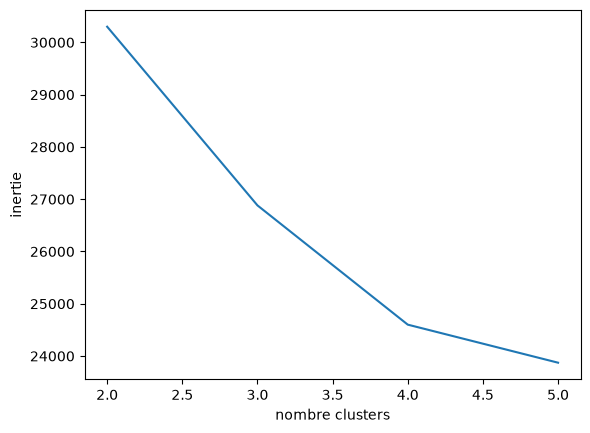

In [23]:
# Elbow
inerties = []

for i in range(2, 6):
    kmeans_model = KMeans(
        n_clusters=i,
        random_state=11
    )
    kmeans_model.fit(X)
    inerties.append(kmeans_model.inertia_)

plt.plot(range(2, 6), inerties)
plt.xlabel('nombre clusters')
plt.ylabel('inertie')
plt.show()

selon le plot le nombre de k idéal est 4.